In [12]:
# Tutorial: https://www.youtube.com/watch?v=pqNCD_5r0IU

In [13]:
import matplotlib.pyplot as plt

In [14]:
x = [i for i in range(10)]
print(x)

y = [i**2 for i in range(10)]
print(y)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


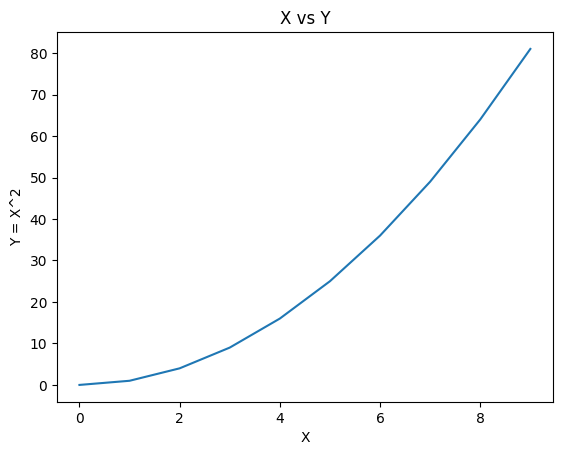

In [15]:
plt.plot(x, y)

plt.xlabel('X')
plt.ylabel('Y = X^2')

plt.title('X vs Y')
plt.show()

In [16]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()

In [17]:
x = iris.data
y = iris.target

print(type(x))
print(type(y))

print(x.shape)
print(y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(150, 4)
(150,)


In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# 80% of 150 rows = 120 rows
print(x_train.shape)
print(x_test.shape)

# 20% of 150 rows = 30 rows
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [19]:
import sklearn
sklearn.__version__

'1.6.1'

In [20]:
# Dataset: http s://archive.ics.uci.edu/dataset/19/car+evaluation

In [21]:
import pandas as pd

car_data = pd.read_csv('car.data', header=None)
car_data_backup = pd.read_csv('car.data', header=None)

car_data.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [22]:
car_data.shape

(1728, 7)

In [23]:
# Fields and values:

# buying:   vhigh, high, med, low
# maint:    vhigh, high, med, low
# doors:    2, 3, 4, 5, more
# persons:  2, 4, more
# lug_boot: small, med, big
# safety:   low, med, high
# class:    unacc, acc, good, vgood


# CAR               car acceptability
# . PRICE           overall price
# . . buying        buying price
# . . maint         price of the maintenance
# . TECH            technical characteristics
# . . COMFORT       comfort
# . . . doors       number of doors
# . . . persons     capacity in terms of persons to carry
# . . . lug_boot    the size of luggage boot
# . . safety        estimated safety of the car

In [24]:
car_data.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
car_data_backup.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

car_data.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [25]:
# Selecting features (x) and labels (y):

x = car_data[['buying', 'maint', 'safety']]
y = car_data[['class']]

print(x.shape)
print(y.shape)

print(type(x))
print(type(y))

(1728, 3)
(1728, 1)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [26]:
# Converting x into a NumPy array:
x = x.values

print(type(x))
print()

print(x)

<class 'numpy.ndarray'>

[['vhigh' 'vhigh' 'low']
 ['vhigh' 'vhigh' 'med']
 ['vhigh' 'vhigh' 'high']
 ...
 ['low' 'low' 'low']
 ['low' 'low' 'med']
 ['low' 'low' 'high']]


In [27]:
# Getting the number of columns for x:
print(x[0])

x_col_count = len(x[0])
print(x_col_count)

['vhigh' 'vhigh' 'low']
3


In [28]:
# Getting all row values for each column in x:
print(x[:, 0])
print(x[:, 1])
print(x[:, 2])

['vhigh' 'vhigh' 'vhigh' ... 'low' 'low' 'low']
['vhigh' 'vhigh' 'vhigh' ... 'low' 'low' 'low']
['low' 'med' 'high' ... 'low' 'med' 'high']


In [29]:
print('Before fit_transform:', x)

Before fit_transform: [['vhigh' 'vhigh' 'low']
 ['vhigh' 'vhigh' 'med']
 ['vhigh' 'vhigh' 'high']
 ...
 ['low' 'low' 'low']
 ['low' 'low' 'med']
 ['low' 'low' 'high']]


In [30]:
# Converting text features into numeric data :

# In fit_transform(),
# the fit() part first learns the mapping, e.g., low becomes 1, med becomes 2, etc.,
# and the transform() part then converts the text data into numeric data according to the learned mapping:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for i in range(x_col_count):
    x[:, i] = le.fit_transform(x[:, i])

print('After fit_transform:', x)

After fit_transform: [[3 3 1]
 [3 3 2]
 [3 3 0]
 ...
 [1 1 1]
 [1 1 2]
 [1 1 0]]


In [31]:
# Mapping for labels (y):

label_mapping = {
    'unacc': 0,
    'acc': 1,
    'good': 2,
    'vgood': 3
}

y['class'] = y['class'].map(label_mapping)
y = y.values

print(y)

[[0]
 [0]
 [0]
 ...
 [0]
 [2]
 [3]]


/tmp/ipykernel_1934/696430097.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['class'] = y['class'].map(label_mapping)


In [32]:
# Creating KNN model:
from sklearn import neighbors

knn = neighbors.KNeighborsClassifier(n_neighbors=25, weights='uniform')

knn

KNeighborsClassifier(n_neighbors=25)

In [33]:
# Fitting the new model on training data only:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

knn.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=25)

In [34]:
# y_predict.shape

y_test.shape

(346, 1)

In [35]:
# Predicting labels of test features:
y_predict = knn.predict(x_test)

print('Predicted labels:')
print(y_predict)

print()
print('Actual labels:')
print(y_test.reshape(-1))

Predicted labels:
[3 0 3 3 1 0 3 2 1 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 3 0 3 3 3 0 0 1 0 3 1 0
 0 3 0 0 1 1 3 1 0 0 1 3 0 1 3 0 0 3 1 3 0 0 0 3 2 1 0 0 1 0 0 0 1 0 0 1 0
 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 2 1 3 1 1 0 0 2 1 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 3 0 0 3 0
 3 3 0 3 2 0 0 0 0 0 0 0 1 0 0 1 1 3 0 0 0 0 1 1 3 0 0 0 0 0 0 3 1 0 0 0 0
 3 0 0 0 0 0 0 0 0 0 0 1 3 0 0 0 0 0 1 2 3 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0
 0 0 0 0 3 3 0 0 0 0 1 3 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 0
 1 0 2 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0 1 3 1 0 1 0 0 0 0 0 0 3 1 0 0
 0 0 0 0 1 3 0 3 0 3 0 0 1 0 0 0 1 1 0 0 0 1 0 3 0 1 0 1 0 3 0 0 1 0 0 0 3
 0 0 3 0 0 1 0 0 0 0 1 0 1]

Actual labels:
[3 0 3 0 0 1 2 2 0 0 0 1 1 1 1 0 1 1 0 1 0 0 1 0 1 2 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 1 0 2 0 0 0 1 0 0 0 0 2 0 3 1 3 0 0 0 3 0 1 0 1 0 0 0 0 1 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 2 0 1 0 0 1 1 0 0 2 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0

In [36]:
# Checking the accuracy of predicted values:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)
print(accuracy)

0.7369942196531792


In [37]:
# Comparing model accuracy against a dumb model:

print('Accuracy of a dumb model which always predicts 0:')
dumb_accuracy_0 = accuracy_score(y_test, 0 * np.ones(len(y_test)))
print(dumb_accuracy_0)

print()
print('Accuracy of a dumb model which always predicts 1:')
dumb_accuracy_1 = accuracy_score(y_test, 1 * np.ones(len(y_test)))
print(dumb_accuracy_1)

print()
print('Accuracy of a dumb model which always predicts 2:')
dumb_accuracy_2 = accuracy_score(y_test, 2 * np.ones(len(y_test)))
print(dumb_accuracy_2)

print()
print('Accuracy of a dumb model which always predicts 3:')
dumb_accuracy_3 = accuracy_score(y_test, 3 * np.ones(len(y_test)))
print(dumb_accuracy_3)

Accuracy of a dumb model which always predicts 0:
0.6820809248554913

Accuracy of a dumb model which always predicts 1:
0.23699421965317918

Accuracy of a dumb model which always predicts 2:
0.049132947976878616

Accuracy of a dumb model which always predicts 3:
0.031791907514450865


In [40]:
# Sample prediction:
print('Actual label #21:', y[20][0])
print('Predicted label #21:', knn.predict(x)[20])

Actual label #21: 0
Predicted label #21: 0


In [ ]:
# Iris dataset: https://archive.ics.uci.edu/dataset/53/iris

In [48]:
print('Description:')
print()
print(iris.DESCR)
print()
print()
print()

print('Data:')
print()
print(iris.data)
print()
print()
print()

print('Data module:')
print()
print(iris.data_module)
print()
print()
print()

print('Feature names:')
print()
print(iris.feature_names)
print()
print()
print()

print('Filename:')
print()
print(iris.filename)
print()
print()
print()

print('Frame:')
print()
print(iris.frame)
print()
print()
print()

print('Target:')
print()
print(iris.target)
print()
print()
print()

print('Target names:')
print()
print(iris.target_names)

Description:

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 

In [55]:
# Creating an SVM model:

x = iris.data
y = iris.target

classes = ['Iris setosa', 'Iris versicolor', 'Iris virginica']

from sklearn import svm

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

print(x.shape)
print(y.shape)
print()
print(x_train.shape)
print(x_test.shape)
print()
print(y_train.shape)
print(y_test.shape)
print()

# C-Support Vector Classification:
model = svm.SVC()
model

(150, 4)
(150,)

(120, 4)
(30, 4)

(120,)
(30,)



SVC()

In [56]:
# Fitting the SVC model:
model.fit(x_train, y_train)
model

SVC()

In [57]:
# Predicting (y_test-equivalent) values using the fitted model:
y_pred = model.predict(x_test)

print(y_pred.shape)
print(y_pred)

(30,)
[0 2 2 2 2 1 0 0 0 1 1 2 2 2 0 0 1 1 2 0 0 2 2 1 2 1 0 1 1 0]


In [61]:
# Checking the accuracy of the
svm_acc = accuracy_score(y_test, y_pred)
print(svm_acc)

0.9666666666666667


In [63]:
# Dataset: https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html

In [ ]:
# The dataset contains a total of 506 cases.


# There are 14 attributes in each case of the dataset:

    # CRIM       - per capita crime rate by town
    # ZN         - proportion of residential land zoned for lots over 25,000 sq.ft.
    # INDUS      - proportion of non-retail business acres per town.
    # CHAS       - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
    # NOX        - nitric oxides concentration (parts per 10 million)
    # RM         - average number of rooms per dwelling
    # AGE        - proportion of owner-occupied units built prior to 1940
    # DIS        - weighted distances to five Boston employment centres
    # RAD        - index of accessibility to radial highways
    # TAX        - full-value property-tax rate per $10,000
    # PTRATIO    - pupil-teacher ratio by town
    # B          - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
    # LSTAT      - % lower status of the population
    # MEDV       - Median value of owner-occupied homes in $1000's


# Here, MEDV is the label and the remaining are the features.

In [89]:
boston_data = pd.read_csv('BostonHousing.csv')
boston_data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [90]:
x = boston_data.drop('medv', axis=1).values
y = boston_data['medv'].values

print(x.shape)
print(y.shape)

(506, 13)
(506,)


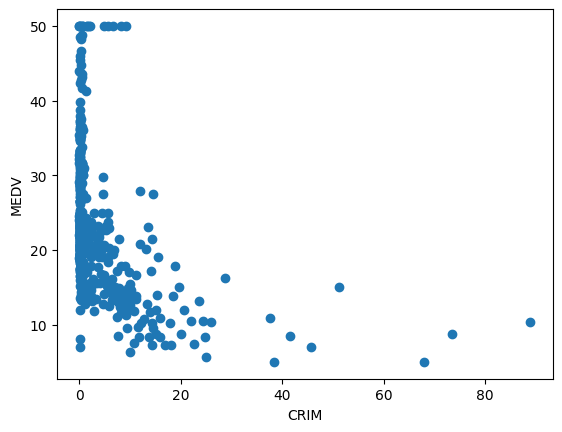

In [91]:
# Comparing the first feature against labels:
plt.scatter(x[:, 0], y)
plt.xlabel('CRIM')
plt.ylabel('MEDV')
plt.show()

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

print(x_train.shape)
print(y_train.shape)
print()
print(x_test.shape)
print(y_test.shape)

(404, 13)
(404,)

(102, 13)
(102,)


In [93]:
# Instantiating the linear regression model:
from sklearn.linear_model import LinearRegression

lin_reg_model = LinearRegression()
lin_reg_model

LinearRegression()

In [94]:
# Ftting the linear regression model:
lin_reg_model.fit(x_train, y_train)
lin_reg_model

LinearRegression()

In [98]:
# Checking the coefficients and intercept:
print(lin_reg_model.coef_)

print()
print(lin_reg_model.intercept_)

[-1.07231826e-01  4.37194378e-02  7.07071431e-02  3.74045193e+00
 -2.05672082e+01  3.42838974e+00  2.50111335e-02 -1.33253423e+00
  3.61828978e-01 -1.32381728e-02 -1.01008463e+00  8.26076655e-03
 -6.28671266e-01]

40.354830979699095


In [102]:
# Predicting test labels (equivalent to y_test):
y_pred = lin_reg_model.predict(x_test)

print(y_test.shape)
print(y_pred.shape)

print()
print(y_test[:5])
print(np.round(y_pred[:5], 2))

(102,)
(102,)

[32.9 20.6 24.4 16.1 20. ]
[29.9  22.37 24.   22.61 19.79]


In [104]:
# Check the R^2 values:
train_score = lin_reg_model.score(x_train, y_train)
test_score = lin_reg_model.score(x_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.7496524830159572
Test R2: 0.6645773047130626
